# PINN × 複變分析：用神經網路求解 Laplace 方程
## Physics-Informed Neural Networks meet Complex Analysis

---

### Project 簡介

本 notebook 展示**複變分析**與 **AI for Science** 的核心交集：

- **複變分析角度**：解析函數 $f(z) = u(x,y) + iv(x,y)$ 的實部 $u$、虛部 $v$ 都滿足 **Laplace 方程** $\nabla^2 u = 0$（由 Cauchy-Riemann 方程推導）
- **AI for Science 角度**：用 **Physics-Informed Neural Network（PINN）** 直接求解 Laplace 方程，不需要有限差分或有限元素法

### 本 Notebook 架構

| 節次 | 內容 | 時間 |
|------|------|------|
| Section 0 | 理論回顧：C-R 方程 → Laplace 方程 | 閱讀 10 min |
| Section 1 | 環境安裝與 GPU 確認 | 執行 2 min |
| Section 2 | 解析解：$f(z)=z^2$ 的 harmonic 函數視覺化 | 執行 3 min |
| Section 3 | PINN 架構設計與訓練 | 執行 10 min |
| Section 4 | PINN 解 vs 解析解的誤差分析 | 執行 3 min |
| Section 5 | Harmonic Conjugate：C-R 條件驗證 | 執行 3 min |
| Section 6 | Domain Coloring：複數映射視覺化 | 執行 3 min |
| Section 7 | 流體力學物理解釋（Bonus） | 執行 2 min |

**總執行時間：約 25–35 分鐘（含閱讀）**

---

> **對應講義**：Teh, Jyh-Haur《Lecture notes on complex analysis》
> - Chapter 2：Complex differentiation（Cauchy-Riemann equations）
> - Chapter 4：Analytic functions
> - Chapter 5：Line integral（Harmonic functions 背景）

---
## Section 0：理論基礎回顧

### 0.1 Cauchy-Riemann 方程

設 $f: \mathbb{C} \to \mathbb{C}$，$f(z) = u(x,y) + iv(x,y)$，$z = x + iy$。

**定理（Ch.2）**：$f$ 在 $z_0$ 可複微分（complex differentiable）若且唯若 $u, v$ 在 $(x_0, y_0)$ 實可微，且滿足：

$$\frac{\partial u}{\partial x} = \frac{\partial v}{\partial y}, \quad \frac{\partial u}{\partial y} = -\frac{\partial v}{\partial x}$$

### 0.2 Harmonic Functions

**推論**：若 $f$ 在區域 $D$ 上解析（analytic），則 $u, v$ 都是 **harmonic functions**，即滿足 Laplace 方程：

$$\nabla^2 u = \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = 0$$

**證明**：由 C-R 方程對 $x$ 微分得 $u_{xx} = v_{yx}$，對 $y$ 微分得 $u_{yy} = -v_{xy}$。由 $v_{xy} = v_{yx}$（Clairaut 定理），故 $u_{xx} + u_{yy} = 0$。$\square$

### 0.3 具體範例：$f(z) = z^2$

$$f(z) = z^2 = (x+iy)^2 = (x^2 - y^2) + i(2xy)$$

所以 $u(x,y) = x^2 - y^2$，$v(x,y) = 2xy$。

驗證 C-R：$u_x = 2x = v_y$ ✓，$u_y = -2y = -v_x$ ✓

驗證 Laplace：$u_{xx} + u_{yy} = 2 + (-2) = 0$ ✓

### 0.4 PINN 的核心思想

**傳統方法**：有限差分法（FDM）將導數離散化，需要建構網格，誤差受網格大小限制。

**PINN 方法**：訓練神經網路 $\hat{u}_\theta(x,y)$，使其同時滿足：
1. **PDE 殘差損失**：$\mathcal{L}_{PDE} = \|\nabla^2 \hat{u}_\theta\|^2$（用自動微分計算偏導數）
2. **邊界條件損失**：$\mathcal{L}_{BC} = \|\hat{u}_\theta - u_{\text{true}}\|^2_{\partial D}$

總損失：$\mathcal{L} = \mathcal{L}_{PDE} + \lambda \cdot \mathcal{L}_{BC}$

**關鍵優勢**：PyTorch 的自動微分（`autograd`）讓我們不需要手動計算偏導數！

---
## Section 1：環境設定

In [13]:
# ============================================================
# Section 1: Environment Setup and GPU Check
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import warnings
warnings.filterwarnings('ignore')

# Fix random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Select device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'  GPU model : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('No GPU found. Training will run on CPU (slower but functional).')

print(f'\nPackage versions:')
print(f'  PyTorch : {torch.__version__}')
print(f'  NumPy   : {np.__version__}')

# Global plot settings
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
print('\nSetup complete.')

Device: cuda
  GPU model : Tesla T4
  VRAM      : 15.6 GB

Package versions:
  PyTorch : 2.11.0+cu128
  NumPy   : 2.0.2

Setup complete.


In [14]:
from google.colab import drive
drive.mount('/content/drive')

import os
import itertools
import matplotlib.pyplot as plt
from IPython import get_ipython

# 你要存圖的資料夾
SAVE_DIR = "/content/drive/MyDrive/PINN_Laplace_ComplexAnalysis"
os.makedirs(SAVE_DIR, exist_ok=True)

# 圖片流水號
_fig_counter = itertools.count(1)

def save_all_open_figures(prefix="figure", dpi=300, close=False):
    """
    把目前所有開著的 matplotlib figures 存成 png。
    close=True 會在存完後關掉圖，避免記憶體累積。
    """
    fig_nums = plt.get_fignums()

    for fig_num in fig_nums:
        fig = plt.figure(fig_num)
        idx = next(_fig_counter)
        filename = f"{prefix}_{idx:03d}.png"
        path = os.path.join(SAVE_DIR, filename)

        fig.savefig(
            path,
            dpi=dpi,
            bbox_inches="tight",
            facecolor="white"
        )
        print(f"Saved: {path}")

    if close:
        plt.close("all")


# 每個 cell 跑完後，自動存目前產生的 matplotlib 圖
def _auto_save_figures_after_cell(*args, **kwargs):
    save_all_open_figures(prefix="colab_output", dpi=300, close=False)

ip = get_ipython()
ip.events.register("post_run_cell", _auto_save_figures_after_cell)

print("Auto-save is ON.")
print(f"Figures will be saved to: {SAVE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Auto-save is ON.
Figures will be saved to: /content/drive/MyDrive/PINN_Laplace_ComplexAnalysis


---
## Section 2：解析解視覺化
### 先用 $f(z) = z^2$ 建立直覺

Max |nabla^2 u| (should be near 0): 1.99e-11


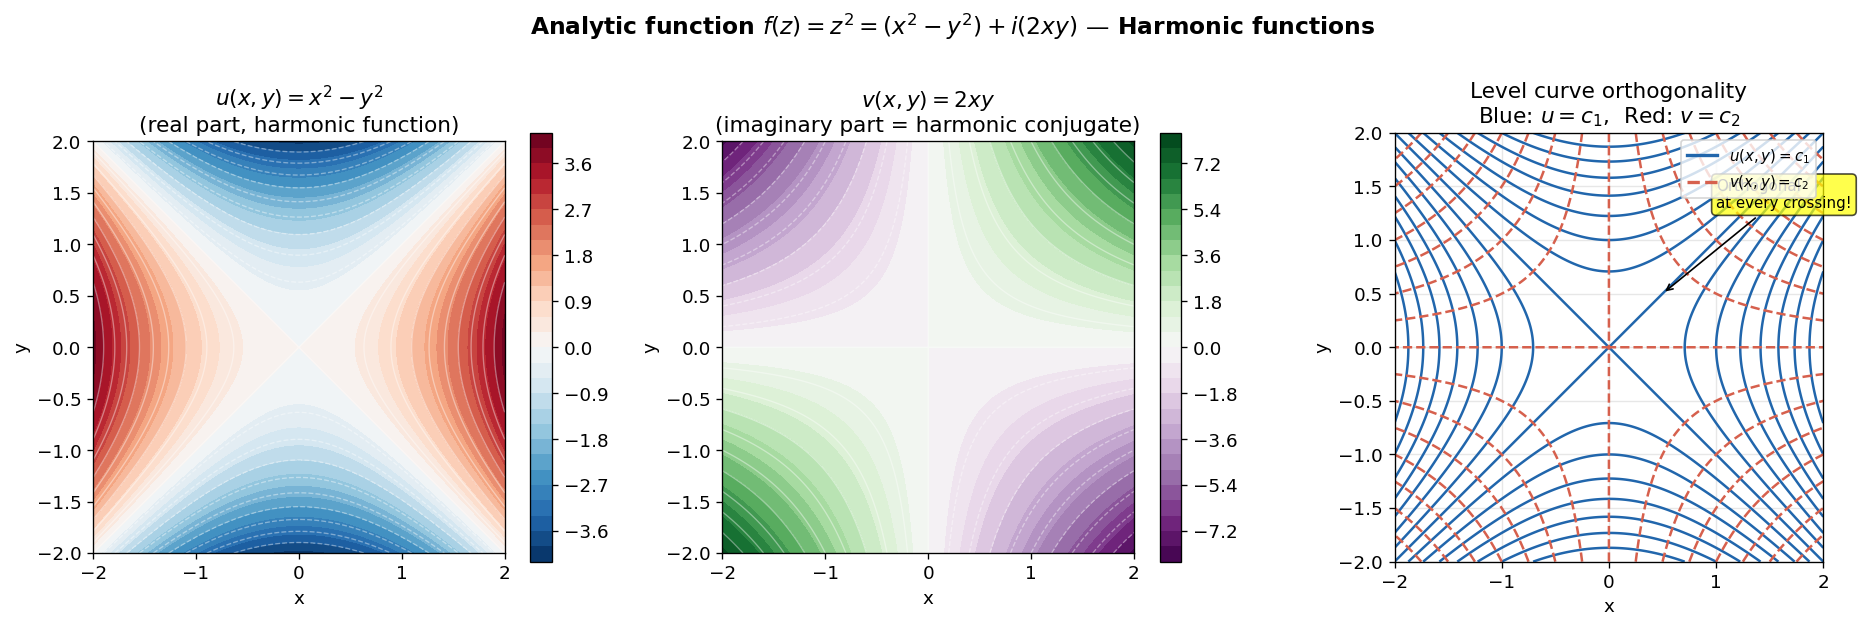


Theory note:
Level curves u=const (blue) and v=const (red) are orthogonal everywhere.
This is the geometric content of the C-R equations: analytic maps are conformal.


In [15]:
# ============================================================
# Section 2: Visualization of the Analytic Solution f(z) = z^2
# ============================================================

# Build evaluation grid
N = 300
x_range = np.linspace(-2, 2, N)
y_range = np.linspace(-2, 2, N)
X, Y = np.meshgrid(x_range, y_range)

# Analytic solution: f(z) = z^2
#   u(x,y) = x^2 - y^2  (real part)
#   v(x,y) = 2xy         (imaginary part = harmonic conjugate)
U_exact = X**2 - Y**2
V_exact = 2 * X * Y

# Numerical verification of the Laplace equation
dx = x_range[1] - x_range[0]
dy = y_range[1] - y_range[0]
laplacian_U = (
    (np.roll(U_exact, -1, axis=1) - 2*U_exact + np.roll(U_exact, 1, axis=1)) / dx**2
  + (np.roll(U_exact, -1, axis=0) - 2*U_exact + np.roll(U_exact, 1, axis=0)) / dy**2
)
print(f'Max |nabla^2 u| (should be near 0): {np.max(np.abs(laplacian_U[5:-5, 5:-5])):.2e}')

# ---- Plotting ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Analytic function $f(z) = z^2 = (x^2-y^2) + i(2xy)$ — Harmonic functions',
             fontsize=14, fontweight='bold', y=1.02)

# Left: u(x,y) = x^2 - y^2
ax = axes[0]
cp = ax.contourf(X, Y, U_exact, levels=30, cmap='RdBu_r')
ax.contour(X, Y, U_exact, levels=20, colors='white', alpha=0.4, linewidths=0.8)
plt.colorbar(cp, ax=ax)
ax.set_title('$u(x,y) = x^2 - y^2$\n(real part, harmonic function)')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')

# Center: v(x,y) = 2xy
ax = axes[1]
cp = ax.contourf(X, Y, V_exact, levels=30, cmap='PRGn')
ax.contour(X, Y, V_exact, levels=20, colors='white', alpha=0.4, linewidths=0.8)
plt.colorbar(cp, ax=ax)
ax.set_title('$v(x,y) = 2xy$\n(imaginary part = harmonic conjugate)')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')

# Right: overlaid level curves — verify orthogonality
ax = axes[2]
ax.contour(X, Y, U_exact, levels=15, colors='#2166ac', linewidths=1.5, linestyles='solid')
ax.contour(X, Y, V_exact, levels=15, colors='#d6604d', linewidths=1.5, linestyles='dashed')
ax.set_title('Level curve orthogonality\nBlue: $u=c_1$,  Red: $v=c_2$')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#2166ac', lw=2, label='$u(x,y) = c_1$'),
    Line2D([0], [0], color='#d6604d', lw=2, linestyle='--', label='$v(x,y) = c_2$')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

ax.annotate('Orthogonal\nat every crossing!', xy=(0.5, 0.5), xytext=(1.0, 1.3),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9, color='black',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.savefig('section2_analytic_solution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTheory note:')
print('Level curves u=const (blue) and v=const (red) are orthogonal everywhere.')
print('This is the geometric content of the C-R equations: analytic maps are conformal.')

---
## Section 3：PINN 模型訓練

### 問題設定

我們求解在矩形區域 $D = [-1,1]^2$ 上的 **Dirichlet 邊界值問題**：

$$\nabla^2 u = 0 \quad \text{in } D$$
$$u(x,y)\big|_{\partial D} = x^2 - y^2 \quad \text{（邊界值 = 解析解的 } u\text{）}$$

真實解：$u(x,y) = x^2 - y^2$

PINN 的任務：在**不知道**內部解的情況下，僅從邊界條件和 PDE 方程式求出 $u$。

In [16]:
# ============================================================
# Section 3.1: PINN Architecture
# ============================================================

class PINN(nn.Module):
    """
    Physics-Informed Neural Network for solving the Laplace equation.

    Architecture: fully connected network with Tanh activations.
    Input : (x, y) coordinates, shape (N, 1) each
    Output: predicted u(x, y), shape (N, 1)

    Why Tanh and not ReLU?
    - Tanh is infinitely differentiable, so autograd can compute stable second derivatives.
    - ReLU has a second derivative that is identically zero almost everywhere,
      making it impossible to enforce a Laplacian constraint.
    """
    def __init__(self, layers=[2, 64, 64, 64, 1]):
        super(PINN, self).__init__()

        # Build the network layer by layer
        self.network = nn.Sequential()
        for i in range(len(layers) - 1):
            self.network.add_module(f'linear_{i}', nn.Linear(layers[i], layers[i+1]))
            if i < len(layers) - 2:   # no activation after the last linear layer
                self.network.add_module(f'tanh_{i}', nn.Tanh())

        # Xavier initialization — important for PINN training stability
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, y):
        inputs = torch.cat([x, y], dim=1)   # concatenate to shape (N, 2)
        return self.network(inputs)


def compute_laplacian(model, x, y):
    """
    Compute the Laplacian  nabla^2 u = u_xx + u_yy  via PyTorch autograd.

    This is the core of PINN: automatic differentiation replaces manual discretization.
    create_graph=True keeps the computation graph alive so that second derivatives
    remain differentiable with respect to the model parameters.
    """
    x.requires_grad_(True)
    y.requires_grad_(True)

    u = model(x, y)

    # First-order partial derivatives
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),
                               create_graph=True, retain_graph=True)[0]
    u_y = torch.autograd.grad(u, y, grad_outputs=torch.ones_like(u),
                               create_graph=True, retain_graph=True)[0]

    # Second-order partial derivatives
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x),
                                create_graph=True, retain_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, grad_outputs=torch.ones_like(u_y),
                                create_graph=True, retain_graph=True)[0]

    laplacian = u_xx + u_yy
    return laplacian, u


# Instantiate model and move to device
model = PINN(layers=[2, 64, 64, 64, 64, 1]).to(device)

total_params = sum(p.numel() for p in model.parameters())
print('PINN model created.')
print(f'  Architecture : Input(2) -> 64 -> 64 -> 64 -> 64 -> Output(1)')
print(f'  Activation   : Tanh (all hidden layers)')
print(f'  Parameters   : {total_params:,}')
print(f'  Device       : {next(model.parameters()).device}')

PINN model created.
  Architecture : Input(2) -> 64 -> 64 -> 64 -> 64 -> Output(1)
  Activation   : Tanh (all hidden layers)
  Parameters   : 12,737
  Device       : cuda:0


Training points generated.
  Interior (PDE residual) : 3000
  Boundary (BC)           : 800


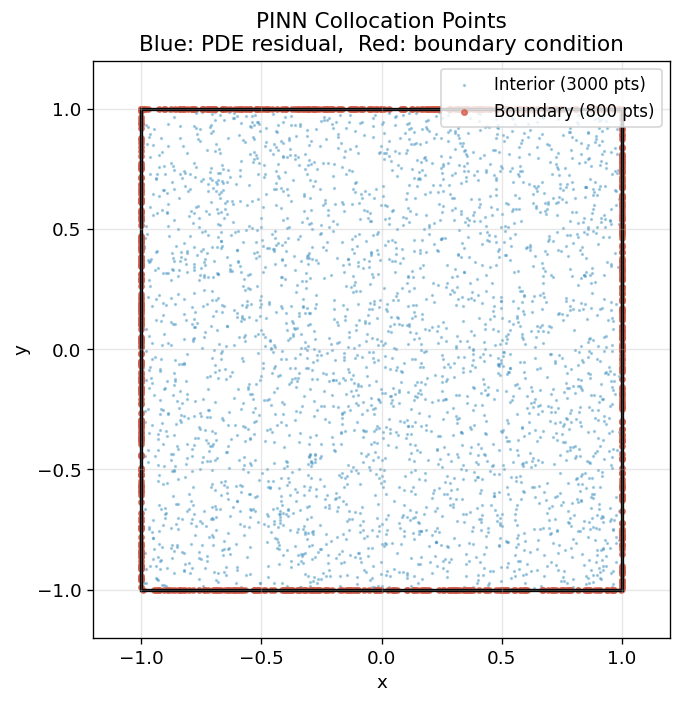

In [17]:
# ============================================================
# Section 3.2: Generate Training Collocation Points
# ============================================================

def generate_training_points(N_interior=2000, N_boundary=500, device='cpu'):
    """
    Generate two sets of collocation points:

    1. Interior points — sampled randomly inside [-1,1]^2.
       Used to enforce the PDE residual (nabla^2 u = 0).

    2. Boundary points — sampled on the four edges of the square.
       Used to enforce the Dirichlet condition u|∂D = x^2 - y^2,
       which is the real part of f(z) = z^2.
    """
    # --- Interior points ---
    x_int = torch.FloatTensor(N_interior, 1).uniform_(-1, 1).to(device)
    y_int = torch.FloatTensor(N_interior, 1).uniform_(-1, 1).to(device)

    # --- Boundary points (equal number on each of the four sides) ---
    N_per_side = N_boundary // 4

    # Bottom edge: y = -1
    x_b1 = torch.FloatTensor(N_per_side, 1).uniform_(-1, 1)
    y_b1 = torch.full((N_per_side, 1), -1.0)

    # Top edge: y = +1
    x_b2 = torch.FloatTensor(N_per_side, 1).uniform_(-1, 1)
    y_b2 = torch.full((N_per_side, 1),  1.0)

    # Left edge: x = -1
    x_b3 = torch.full((N_per_side, 1), -1.0)
    y_b3 = torch.FloatTensor(N_per_side, 1).uniform_(-1, 1)

    # Right edge: x = +1
    x_b4 = torch.full((N_per_side, 1),  1.0)
    y_b4 = torch.FloatTensor(N_per_side, 1).uniform_(-1, 1)

    x_bnd = torch.cat([x_b1, x_b2, x_b3, x_b4], dim=0).to(device)
    y_bnd = torch.cat([y_b1, y_b2, y_b3, y_b4], dim=0).to(device)

    # Ground-truth boundary values: u = x^2 - y^2
    u_bnd_true = (x_bnd**2 - y_bnd**2).to(device)

    return x_int, y_int, x_bnd, y_bnd, u_bnd_true


x_int, y_int, x_bnd, y_bnd, u_bnd_true = generate_training_points(
    N_interior=3000, N_boundary=800, device=device
)

print('Training points generated.')
print(f'  Interior (PDE residual) : {x_int.shape[0]}')
print(f'  Boundary (BC)           : {x_bnd.shape[0]}')

# Visualize point distribution
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(x_int.cpu().numpy(), y_int.cpu().numpy(),
           s=1, c='#4393c3', alpha=0.4, label=f'Interior ({x_int.shape[0]} pts)')
ax.scatter(x_bnd.cpu().numpy(), y_bnd.cpu().numpy(),
           s=10, c='#d6604d', alpha=0.8, label=f'Boundary ({x_bnd.shape[0]} pts)')
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('PINN Collocation Points\nBlue: PDE residual,  Red: boundary condition')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
rect = plt.Rectangle((-1, -1), 2, 2, fill=False, edgecolor='black', linewidth=2)
ax.add_patch(rect)
plt.tight_layout()
plt.savefig('section3_training_points.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ============================================================
# Section 3.3: Loss Function and Training Loop
# ============================================================

# Optimizer and learning-rate scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

# Hyperparameters
EPOCHS      = 8000
LAMBDA_BC   = 10.0   # weight on the boundary-condition loss
LOG_INTERVAL = 500

# Training history
history = {'total': [], 'pde': [], 'bc': [], 'epoch': []}

print('Starting PINN training...')
print(f'  Epochs       : {EPOCHS}')
print(f'  Learning rate: 1e-3  (x0.5 every 2000 steps)')
print(f'  lambda_BC    : {LAMBDA_BC}')
print('-' * 55)
print(f'{"Epoch":>7} | {"Total Loss":>12} | {"PDE Loss":>12} | {"BC Loss":>12}')
print('-' * 55)

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()

    # --- Loss 1: PDE residual  (nabla^2 u = 0) ---
    # Resample interior points every epoch so the network sees varied locations
    x_i = torch.FloatTensor(2000, 1).uniform_(-1, 1).to(device)
    y_i = torch.FloatTensor(2000, 1).uniform_(-1, 1).to(device)

    laplacian, _ = compute_laplacian(model, x_i, y_i)
    loss_pde = torch.mean(laplacian**2)

    # --- Loss 2: Boundary condition ---
    u_pred_bnd = model(x_bnd, y_bnd)
    loss_bc = torch.mean((u_pred_bnd - u_bnd_true)**2)

    # --- Total loss ---
    loss = loss_pde + LAMBDA_BC * loss_bc

    loss.backward()

    # Gradient clipping prevents exploding gradients
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()
    scheduler.step()

    # Record history every 50 epochs
    if epoch % 50 == 0:
        history['epoch'].append(epoch)
        history['total'].append(loss.item())
        history['pde'].append(loss_pde.item())
        history['bc'].append(loss_bc.item())

    # Print progress
    if epoch % LOG_INTERVAL == 0:
        print(f'{epoch:>7} | {loss.item():>12.6f} | {loss_pde.item():>12.6f} | {loss_bc.item():>12.6f}')

print('-' * 55)
print('Training complete.')

Starting PINN training...
  Epochs       : 8000
  Learning rate: 1e-3  (x0.5 every 2000 steps)
  lambda_BC    : 10.0
-------------------------------------------------------
  Epoch |   Total Loss |     PDE Loss |      BC Loss
-------------------------------------------------------
    500 |     0.006101 |     0.000613 |     0.000549
   1000 |     0.005363 |     0.000443 |     0.000492
   1500 |     0.004729 |     0.000379 |     0.000435
   2000 |     0.005254 |     0.000512 |     0.000474
   2500 |     0.000051 |     0.000044 |     0.000001
   3000 |     0.000633 |     0.000075 |     0.000056
   3500 |     0.000218 |     0.000039 |     0.000018
   4000 |     0.001205 |     0.000129 |     0.000108
   4500 |     0.000027 |     0.000025 |     0.000000
   5000 |     0.000026 |     0.000024 |     0.000000
   5500 |     0.000020 |     0.000019 |     0.000000
   6000 |     0.000024 |     0.000019 |     0.000000
   6500 |     0.000018 |     0.000017 |     0.000000
   7000 |     0.000016 |     

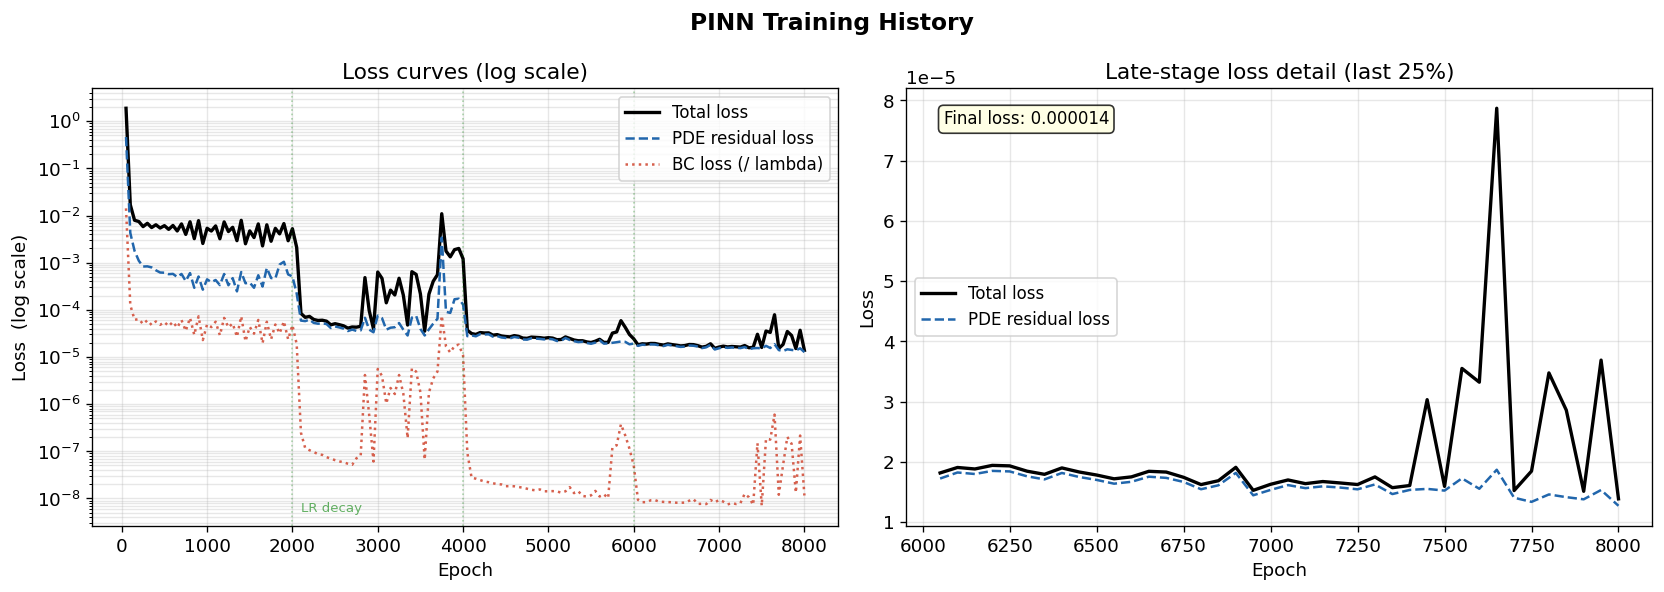

In [19]:
# ============================================================
# Section 3.4: Training Curve Visualization
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PINN Training History', fontsize=14, fontweight='bold')

# Left: all three loss curves on a log scale
ax = axes[0]
epochs_log = history['epoch']
ax.semilogy(epochs_log, history['total'], 'k-',          linewidth=2,   label='Total loss')
ax.semilogy(epochs_log, history['pde'],   color='#2166ac', linewidth=1.5,
            linestyle='--', label='PDE residual loss')
ax.semilogy(epochs_log, [v / LAMBDA_BC for v in history['bc']],
            color='#d6604d', linewidth=1.5, linestyle=':', label='BC loss (/ lambda)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss  (log scale)')
ax.set_title('Loss curves (log scale)')
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)
# Mark learning-rate decay steps
for lr_step in [2000, 4000, 6000]:
    ax.axvline(x=lr_step, color='green', alpha=0.3, linestyle=':', linewidth=1)
ax.text(2100, ax.get_ylim()[0] * 2, 'LR decay', fontsize=8, color='green', alpha=0.6)

# Right: late-stage loss detail (last 25% of training)
ax = axes[1]
cutoff = len(epochs_log) * 3 // 4
ax.plot(epochs_log[cutoff:], history['total'][cutoff:], 'k-',          linewidth=2,   label='Total loss')
ax.plot(epochs_log[cutoff:], history['pde'][cutoff:],   color='#2166ac', linewidth=1.5,
        linestyle='--', label='PDE residual loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Late-stage loss detail (last 25%)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

final_loss = history['total'][-1]
ax.text(0.05, 0.95, f'Final loss: {final_loss:.6f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('section3_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4：PINN 解 vs 解析解的誤差分析

Error statistics:
  L2 error   : 0.000215
  Max error  : 0.001148
  Mean error : 0.000193


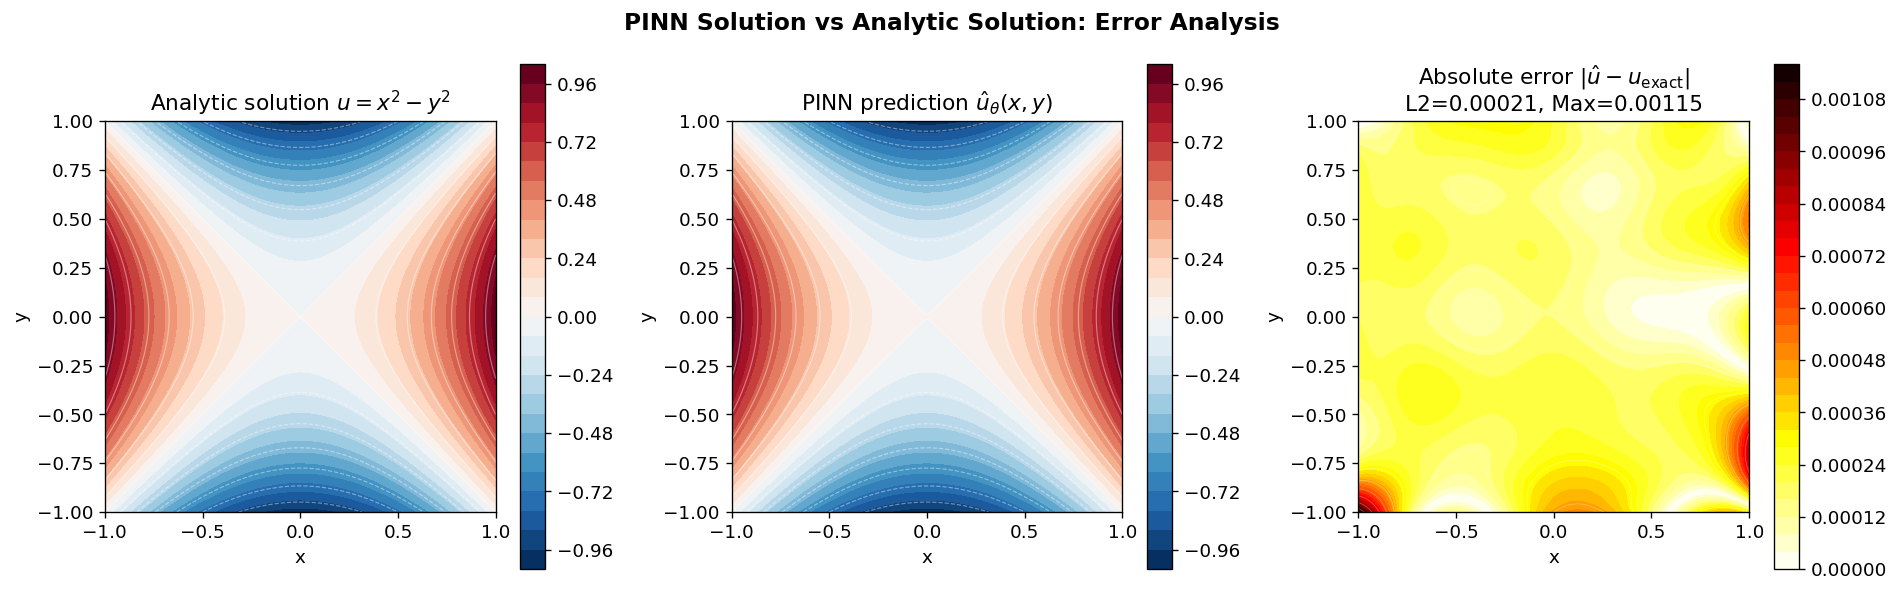

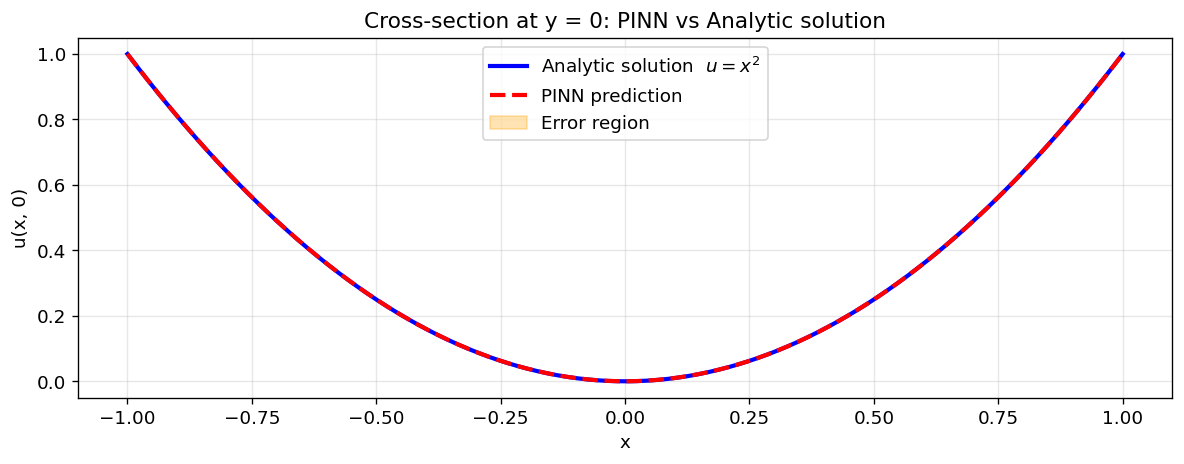

In [20]:
# ============================================================
# Section 4: Error Analysis — PINN vs Analytic Solution
# ============================================================

model.eval()

# Dense evaluation grid
N_eval = 200
x_eval = np.linspace(-1, 1, N_eval)
y_eval = np.linspace(-1, 1, N_eval)
X_eval, Y_eval = np.meshgrid(x_eval, y_eval)

x_t = torch.FloatTensor(X_eval.flatten()).unsqueeze(1).to(device)
y_t = torch.FloatTensor(Y_eval.flatten()).unsqueeze(1).to(device)

# Network prediction (no gradient tracking needed)
with torch.no_grad():
    u_pred = model(x_t, y_t).cpu().numpy().reshape(N_eval, N_eval)

# Analytic solution
u_exact = X_eval**2 - Y_eval**2

# Error metrics
error      = np.abs(u_pred - u_exact)
l2_error   = np.sqrt(np.mean(error**2))
max_error  = np.max(error)
mean_error = np.mean(error)
print('Error statistics:')
print(f'  L2 error   : {l2_error:.6f}')
print(f'  Max error  : {max_error:.6f}')
print(f'  Mean error : {mean_error:.6f}')

# ---- Plotting ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('PINN Solution vs Analytic Solution: Error Analysis',
             fontsize=14, fontweight='bold')

vmin = min(u_pred.min(), u_exact.min())
vmax = max(u_pred.max(), u_exact.max())

# Left: analytic solution
ax = axes[0]
im = ax.contourf(X_eval, Y_eval, u_exact, levels=30, cmap='RdBu_r', vmin=vmin, vmax=vmax)
ax.contour(X_eval, Y_eval, u_exact, levels=15, colors='white', alpha=0.4, linewidths=0.7)
plt.colorbar(im, ax=ax)
ax.set_title('Analytic solution $u = x^2 - y^2$')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')

# Center: PINN prediction
ax = axes[1]
im = ax.contourf(X_eval, Y_eval, u_pred, levels=30, cmap='RdBu_r', vmin=vmin, vmax=vmax)
ax.contour(X_eval, Y_eval, u_pred, levels=15, colors='white', alpha=0.4, linewidths=0.7)
plt.colorbar(im, ax=ax)
ax.set_title('PINN prediction $\\hat{u}_{\\theta}(x,y)$')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')

# Right: pointwise absolute error heatmap
ax = axes[2]
im = ax.contourf(X_eval, Y_eval, error, levels=30, cmap='hot_r')
ax.contour(X_eval, Y_eval, error, levels=10, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(im, ax=ax)
ax.set_title(f'Absolute error $|\\hat{{u}} - u_{{\\mathrm{{exact}}}}|$\nL2={l2_error:.5f}, Max={max_error:.5f}')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('section4_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Cross-section comparison along y = 0
fig, ax = plt.subplots(figsize=(10, 4))
mid = N_eval // 2
ax.plot(x_eval, u_exact[mid, :], 'b-',  linewidth=2.5, label='Analytic solution  $u = x^2$')
ax.plot(x_eval, u_pred[mid, :],  'r--', linewidth=2.5, label='PINN prediction')
ax.fill_between(x_eval, u_exact[mid, :], u_pred[mid, :],
                alpha=0.3, color='orange', label='Error region')
ax.set_xlabel('x'); ax.set_ylabel('u(x, 0)')
ax.set_title('Cross-section at y = 0: PINN vs Analytic solution')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('section4_cross_section.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 5：Harmonic Conjugate 與 C-R 條件驗證

從 PINN 學到的 $u(x,y)$ 出發，用 Cauchy-Riemann 方程數值計算其 harmonic conjugate $v(x,y)$：

$$v_y = u_x, \quad v_x = -u_y \quad \Rightarrow \quad v(x,y) = \int_0^y u_x(x,t)\,dt$$

C-R check (u_x = v_y) — mean absolute error: 0.0000


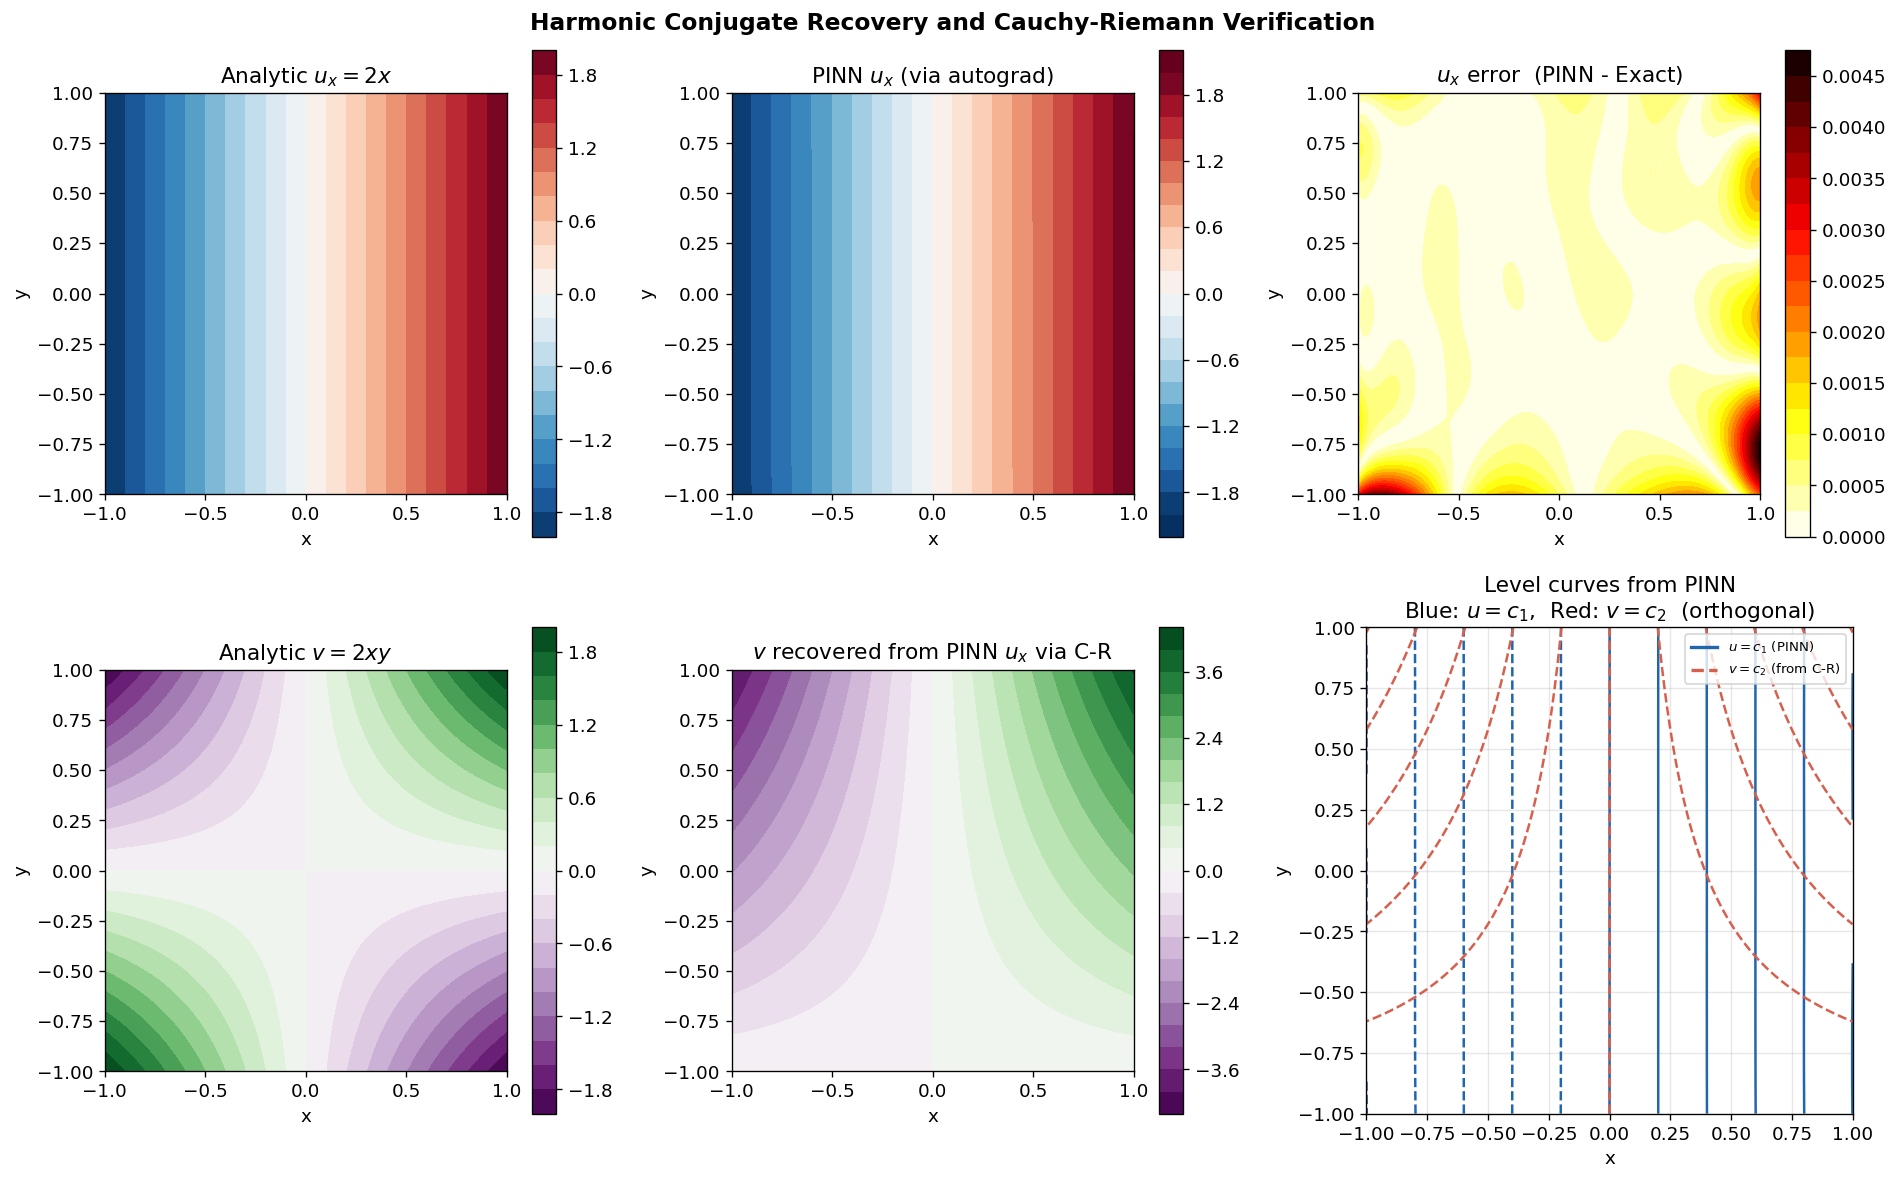

In [21]:
# ============================================================
# Section 5: Harmonic Conjugate Recovery and C-R Verification
# ============================================================

# Build a grid for the gradient computation
N_cr = 100
x_cr = np.linspace(-1, 1, N_cr)
y_cr = np.linspace(-1, 1, N_cr)
X_cr, Y_cr = np.meshgrid(x_cr, y_cr)

x_t = torch.FloatTensor(X_cr.flatten()).unsqueeze(1).to(device)
y_t = torch.FloatTensor(Y_cr.flatten()).unsqueeze(1).to(device)
x_t.requires_grad_(True)
y_t.requires_grad_(True)

u_out = model(x_t, y_t)

# Compute u_x and u_y via autograd
u_x_pinn = torch.autograd.grad(u_out, x_t, grad_outputs=torch.ones_like(u_out),
                                create_graph=False, retain_graph=True)[0]
u_y_pinn = torch.autograd.grad(u_out, y_t, grad_outputs=torch.ones_like(u_out),
                                create_graph=False)[0]

u_x_np = u_x_pinn.detach().cpu().numpy().reshape(N_cr, N_cr)
u_y_np = u_y_pinn.detach().cpu().numpy().reshape(N_cr, N_cr)

# Analytic gradients for comparison
u_x_exact = 2 * X_cr    # d(x^2-y^2)/dx = 2x
u_y_exact = -2 * Y_cr   # d(x^2-y^2)/dy = -2y

# Recover harmonic conjugate v via the C-R relation  v_y = u_x:
#   v(x,y) = integral_0^y  u_x(x,t) dt   (numerical integration along y)
dy_cr  = y_cr[1] - y_cr[0]
V_pinn  = np.cumsum(u_x_np, axis=0) * dy_cr
V_exact = 2 * X_cr * Y_cr

# Correct the integration constant so the means match
V_pinn = V_pinn - np.mean(V_pinn) + np.mean(V_exact)

# Verify C-R condition  u_x = v_y  numerically
v_y_num   = np.gradient(V_pinn, dy_cr, axis=0)
cr_error  = np.abs(u_x_np - v_y_num)
print(f'C-R check (u_x = v_y) — mean absolute error: {np.mean(cr_error):.4f}')

# ---- Plotting ----
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Harmonic Conjugate Recovery and Cauchy-Riemann Verification',
             fontsize=14, fontweight='bold')

vmax_grad = max(np.abs(u_x_exact).max(), np.abs(u_x_np).max())

# Row 1: u_x comparison
ax = axes[0, 0]
im = ax.contourf(X_cr, Y_cr, u_x_exact, levels=20, cmap='RdBu_r',
                 vmin=-vmax_grad, vmax=vmax_grad)
plt.colorbar(im, ax=ax)
ax.set_title('Analytic $u_x = 2x$')
ax.set_aspect('equal')

ax = axes[0, 1]
im = ax.contourf(X_cr, Y_cr, u_x_np, levels=20, cmap='RdBu_r',
                 vmin=-vmax_grad, vmax=vmax_grad)
plt.colorbar(im, ax=ax)
ax.set_title('PINN $u_x$ (via autograd)')
ax.set_aspect('equal')

ax = axes[0, 2]
im = ax.contourf(X_cr, Y_cr, np.abs(u_x_np - u_x_exact), levels=20, cmap='hot_r')
plt.colorbar(im, ax=ax)
ax.set_title('$u_x$ error  (PINN - Exact)')
ax.set_aspect('equal')

# Row 2: harmonic conjugate v comparison
ax = axes[1, 0]
im = ax.contourf(X_cr, Y_cr, V_exact, levels=20, cmap='PRGn')
plt.colorbar(im, ax=ax)
ax.set_title('Analytic $v = 2xy$')
ax.set_aspect('equal')

ax = axes[1, 1]
im = ax.contourf(X_cr, Y_cr, V_pinn, levels=20, cmap='PRGn')
plt.colorbar(im, ax=ax)
ax.set_title('$v$ recovered from PINN $u_x$ via C-R')
ax.set_aspect('equal')

ax = axes[1, 2]
# Final orthogonality verification
ax.contour(X_cr, Y_cr, u_x_np, levels=12, colors='#2166ac', linewidths=1.5)
ax.contour(X_cr, Y_cr, V_pinn, levels=12, colors='#d6604d', linewidths=1.5, linestyles='--')
ax.set_title('Level curves from PINN\nBlue: $u=c_1$,  Red: $v=c_2$  (orthogonal)')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#2166ac', lw=2,            label='$u = c_1$ (PINN)'),
    Line2D([0], [0], color='#d6604d', lw=2, ls='--',   label='$v = c_2$ (from C-R)')
]
ax.legend(handles=legend_elements, fontsize=8)

for ax in axes.flatten():
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.tight_layout()
plt.savefig('section5_harmonic_conjugate.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 6：Domain Coloring — 複數映射視覺化

**Domain Coloring** 是視覺化複數函數 $f: \mathbb{C} \to \mathbb{C}$ 最直觀的方式：
- **色相（Hue）**：代表 $\arg(f(z))$，即 $f(z)$ 的輻角
- **亮度（Brightness）**：代表 $|f(z)|$，即 $f(z)$ 的模

這樣一張圖就能完整展現複數函數的幾何行為！

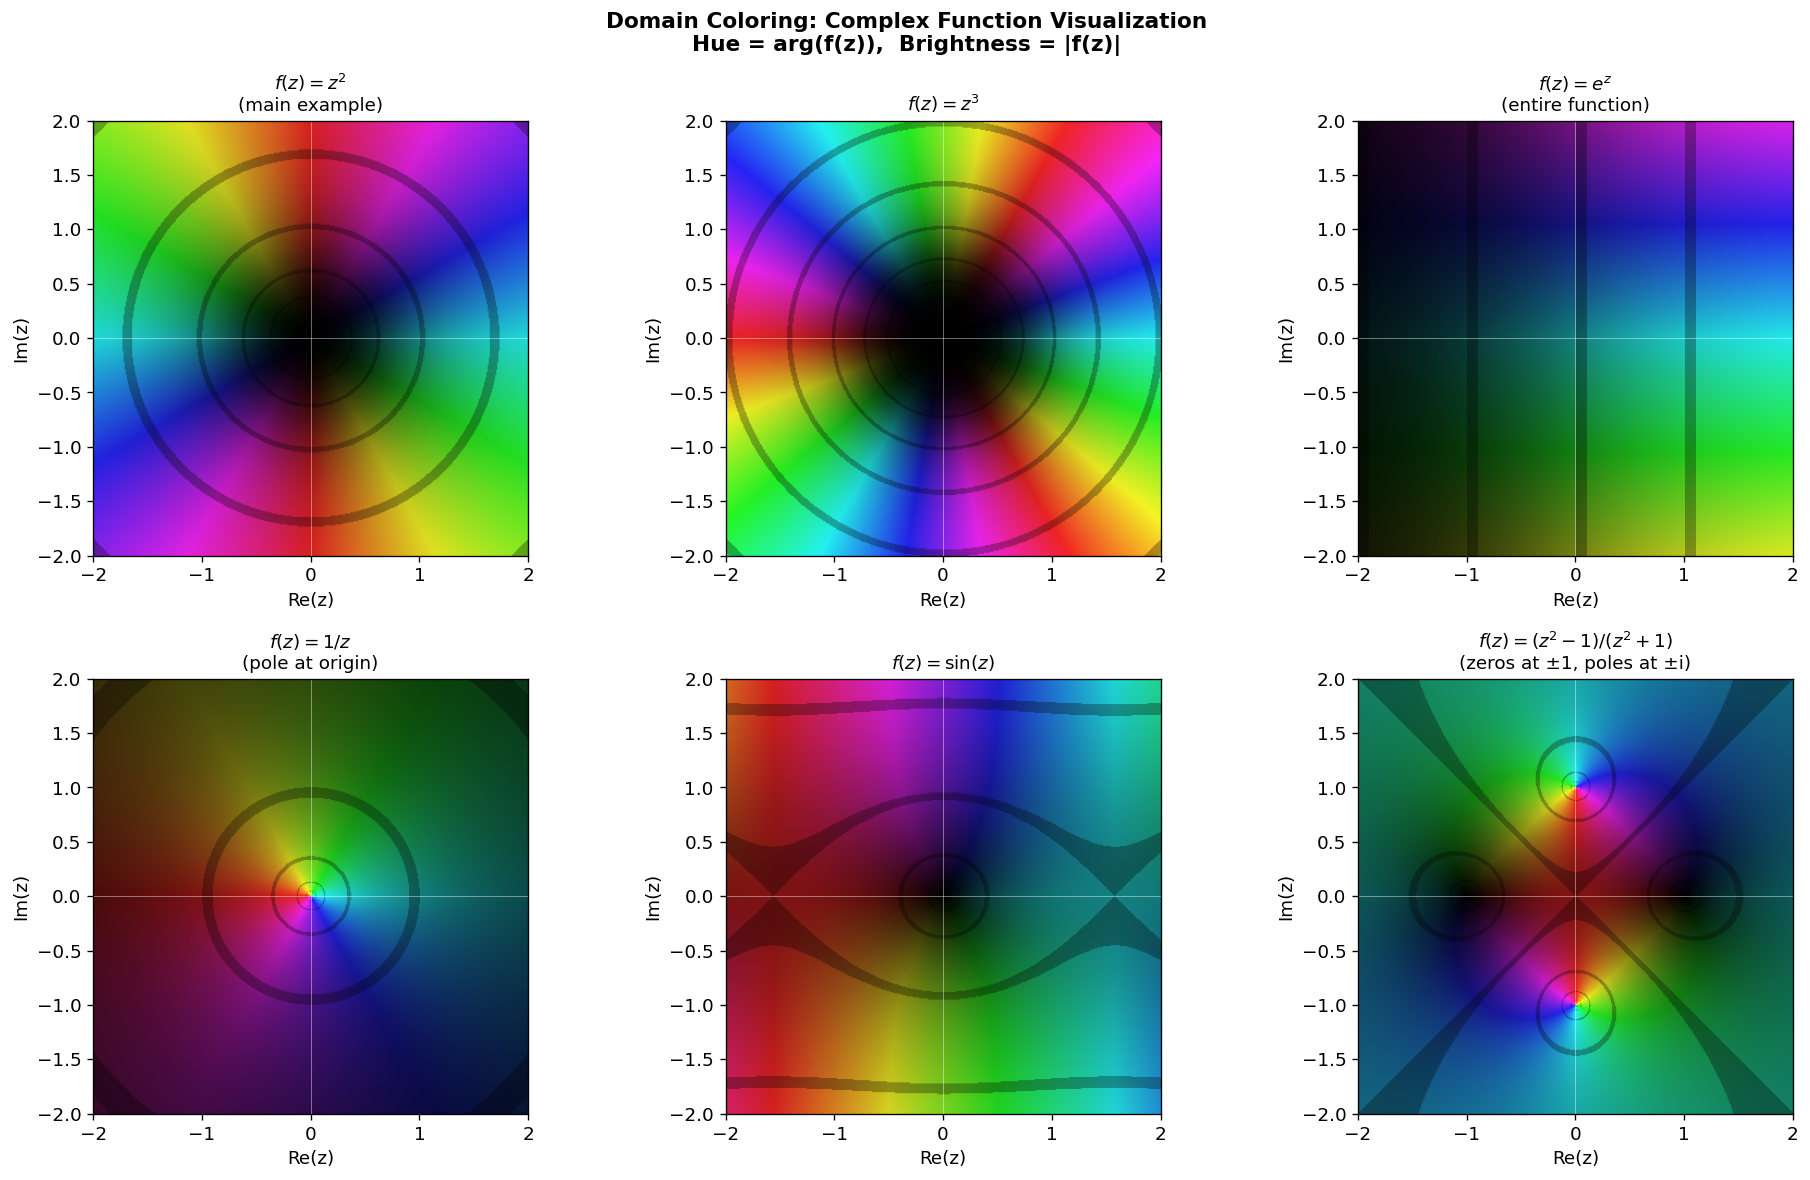

How to read Domain Coloring:
  One full hue cycle around a point = one zero or pole of f(z).
  Counterclockwise hue cycle -> zero.
  Clockwise hue cycle        -> pole.
  f(z) = z^n has an n-th order zero at the origin: count n hue cycles!


In [22]:
# ============================================================
# Section 6: Domain Coloring of Complex Functions
# ============================================================

def domain_coloring(f_complex, x_range=(-2, 2), y_range=(-2, 2), N=400):
    """
    Generate a domain coloring image for the complex function f(z).

    Color encoding:
      Hue        <- arg(f(z))  mapped to [0, 1]
      Value      <- |f(z)|    compressed with (2/pi) * arctan to [0, 1]
      Saturation <- constant 0.85

    Modulus contour lines (every e-fold) are darkened slightly
    to make the magnitude structure visible.

    Returns:
        RGB  : (N, N, 3) float array in [0, 1]
        x, y : 1-D coordinate arrays
    """
    x = np.linspace(x_range[0], x_range[1], N)
    y = np.linspace(y_range[0], y_range[1], N)
    X_dc, Y_dc = np.meshgrid(x, y)
    Z = X_dc + 1j * Y_dc

    W = f_complex(Z)

    hue        = (np.angle(W) + np.pi) / (2 * np.pi)
    magnitude  = np.abs(W)
    value      = 2 / np.pi * np.arctan(magnitude)
    saturation = np.ones_like(hue) * 0.85

    HSV = np.dstack([hue, saturation, value])
    RGB = mcolors.hsv_to_rgb(HSV)

    # Darken modulus contour lines
    log_mag    = np.log(magnitude + 1e-10)
    grid_lines = (log_mag % 1.0) < 0.1
    RGB[grid_lines] *= 0.7

    return RGB, x, y


# Functions to visualize
functions = [
    (lambda z: z**2,              '$f(z) = z^2$\n(main example)'),
    (lambda z: z**3,              '$f(z) = z^3$'),
    (lambda z: np.exp(z),         '$f(z) = e^z$\n(entire function)'),
    (lambda z: 1/z,               '$f(z) = 1/z$\n(pole at origin)'),
    (lambda z: np.sin(z),         '$f(z) = \\sin(z)$'),
    (lambda z: (z**2-1)/(z**2+1), '$f(z) = (z^2-1)/(z^2+1)$\n(zeros at ±1, poles at ±i)'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Domain Coloring: Complex Function Visualization\nHue = arg(f(z)),  Brightness = |f(z)|',
             fontsize=13, fontweight='bold')

for ax, (f, title) in zip(axes.flatten(), functions):
    RGB, x_dc, y_dc = domain_coloring(f, x_range=(-2, 2), y_range=(-2, 2), N=400)
    ax.imshow(RGB, extent=[-2, 2, -2, 2], origin='lower', aspect='equal')
    ax.axhline(y=0, color='white', linewidth=0.5, alpha=0.5)
    ax.axvline(x=0, color='white', linewidth=0.5, alpha=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Re(z)'); ax.set_ylabel('Im(z)')

plt.tight_layout()
plt.savefig('section6_domain_coloring.png', dpi=150, bbox_inches='tight')
plt.show()

print('How to read Domain Coloring:')
print('  One full hue cycle around a point = one zero or pole of f(z).')
print('  Counterclockwise hue cycle -> zero.')
print('  Clockwise hue cycle        -> pole.')
print('  f(z) = z^n has an n-th order zero at the origin: count n hue cycles!')

---
## Section 7：流體力學的物理意義（Bonus）

Harmonic functions 在物理上的核心應用：**二維無旋不可壓縮流**

- $u(x,y)$：**速度勢**（velocity potential），$\vec{v} = \nabla u$
- $v(x,y)$：**流函數**（stream function），流線 = $v = \mathrm{const}$ 的曲線
- 等位線 $u = \mathrm{const}$（equipotential lines）和流線 $v = \mathrm{const}$（streamlines）**正交**

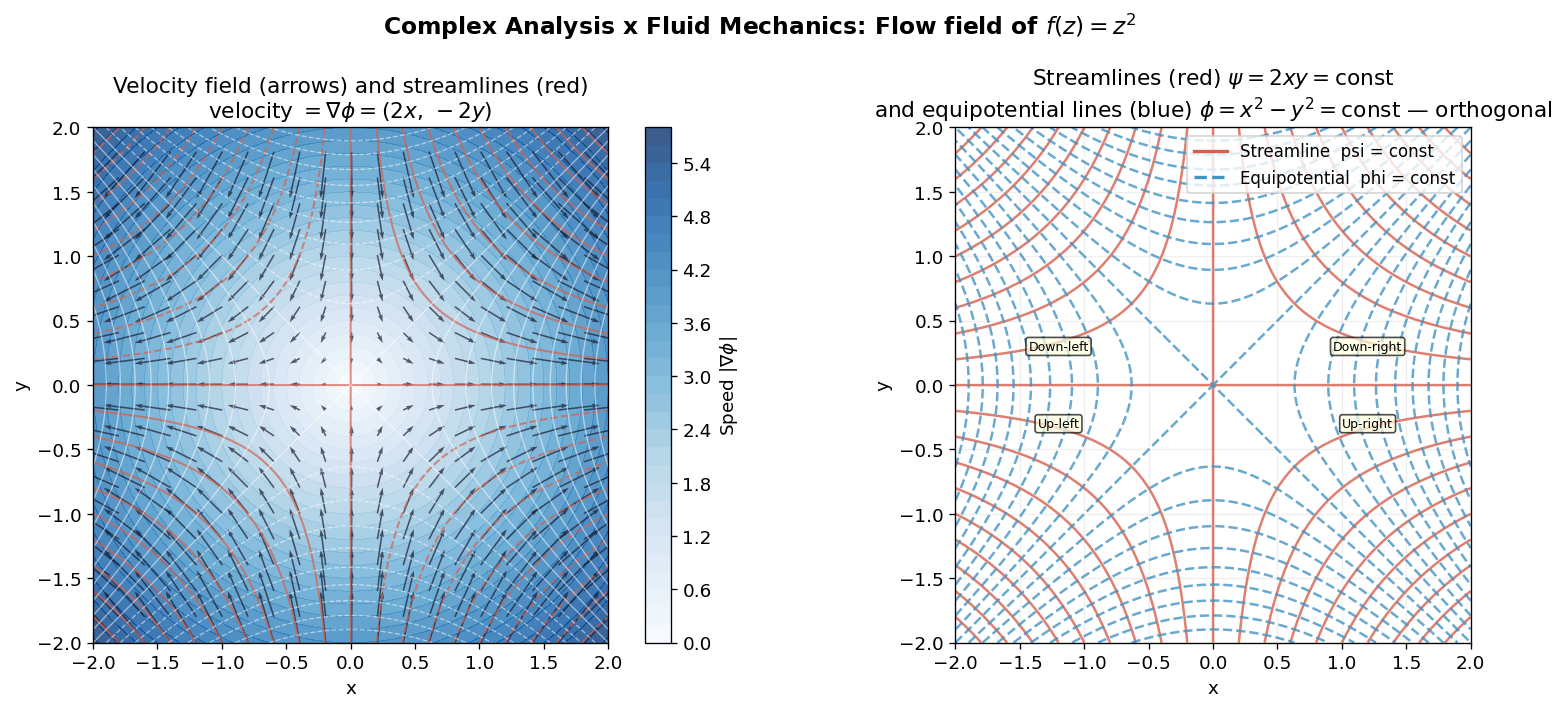

Physical interpretation:
  f(z) = z^2 describes ideal fluid flow around a right-angle corner (corner flow).
  - Speed is zero at the origin (stagnation point).
  - Flow is symmetric with respect to both axes.
  - This is the canonical model for fluid rounding a 90-degree bend in engineering.


In [23]:
# ============================================================
# Section 7: Fluid Flow Visualization
# ============================================================

N_fluid = 300
x_f = np.linspace(-2, 2, N_fluid)
y_f = np.linspace(-2, 2, N_fluid)
X_f, Y_f = np.meshgrid(x_f, y_f)

# Interpretation of f(z) = z^2 as a potential flow:
#   phi (velocity potential) = Re(f) = x^2 - y^2
#   psi (stream function)    = Im(f) = 2xy
phi   = X_f**2 - Y_f**2   # velocity potential
psi   = 2 * X_f * Y_f     # stream function

# Velocity field: v = grad(phi)
vx    = 2 * X_f            # d phi/dx
vy    = -2 * Y_f           # d phi/dy
speed = np.sqrt(vx**2 + vy**2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Complex Analysis x Fluid Mechanics: Flow field of $f(z) = z^2$',
             fontsize=14, fontweight='bold')

# Left: velocity field with streamlines
ax = axes[0]
speed_plot = ax.contourf(X_f, Y_f, speed, levels=30, cmap='Blues', alpha=0.8)
plt.colorbar(speed_plot, ax=ax, label='Speed $|\\nabla\\phi|$')
step = 15
ax.quiver(X_f[::step, ::step], Y_f[::step, ::step],
          vx[::step, ::step], vy[::step, ::step],
          color='#1a1a2e', alpha=0.7, scale=40, width=0.003)
ax.contour(X_f, Y_f, psi, levels=20, colors='#d6604d', linewidths=1.2, alpha=0.7)
ax.contour(X_f, Y_f, phi, levels=20, colors='white',   linewidths=0.8, alpha=0.5)
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.set_aspect('equal')
ax.set_title('Velocity field (arrows) and streamlines (red)\n'
             'velocity $= \\nabla\\phi = (2x,\\,-2y)$')
ax.set_xlabel('x'); ax.set_ylabel('y')

# Right: orthogonality of streamlines and equipotential lines
ax = axes[1]
ax.contour(X_f, Y_f, psi, levels=25, colors='#d6604d',
           linewidths=1.5, linestyles='solid',  alpha=0.8)
ax.contour(X_f, Y_f, phi, levels=25, colors='#4393c3',
           linewidths=1.5, linestyles='dashed', alpha=0.8)
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.set_aspect('equal')
ax.set_title('Streamlines (red) $\\psi=2xy=\\mathrm{const}$\n'
             'and equipotential lines (blue) $\\phi=x^2-y^2=\\mathrm{const}$ — orthogonal')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.grid(True, alpha=0.2)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#d6604d', lw=2,         label='Streamline  psi = const'),
    Line2D([0], [0], color='#4393c3', lw=2, ls='--', label='Equipotential  phi = const'),
]
ax.legend(handles=legend_elements, fontsize=10, loc='upper right')

# Flow direction annotations
annotations = [
    ( 1.2,  0.3, 'Down-right'),
    (-1.2,  0.3, 'Down-left'),
    ( 1.2, -0.3, 'Up-right'),
    (-1.2, -0.3, 'Up-left'),
]
for xp, yp, text in annotations:
    ax.text(xp, yp, text, fontsize=7.5, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
plt.savefig('section7_fluid_flow.png', dpi=150, bbox_inches='tight')
plt.show()

print('Physical interpretation:')
print('  f(z) = z^2 describes ideal fluid flow around a right-angle corner (corner flow).')
print('  - Speed is zero at the origin (stagnation point).')
print('  - Flow is symmetric with respect to both axes.')
print('  - This is the canonical model for fluid rounding a 90-degree bend in engineering.')

---
## 總結與成果展示

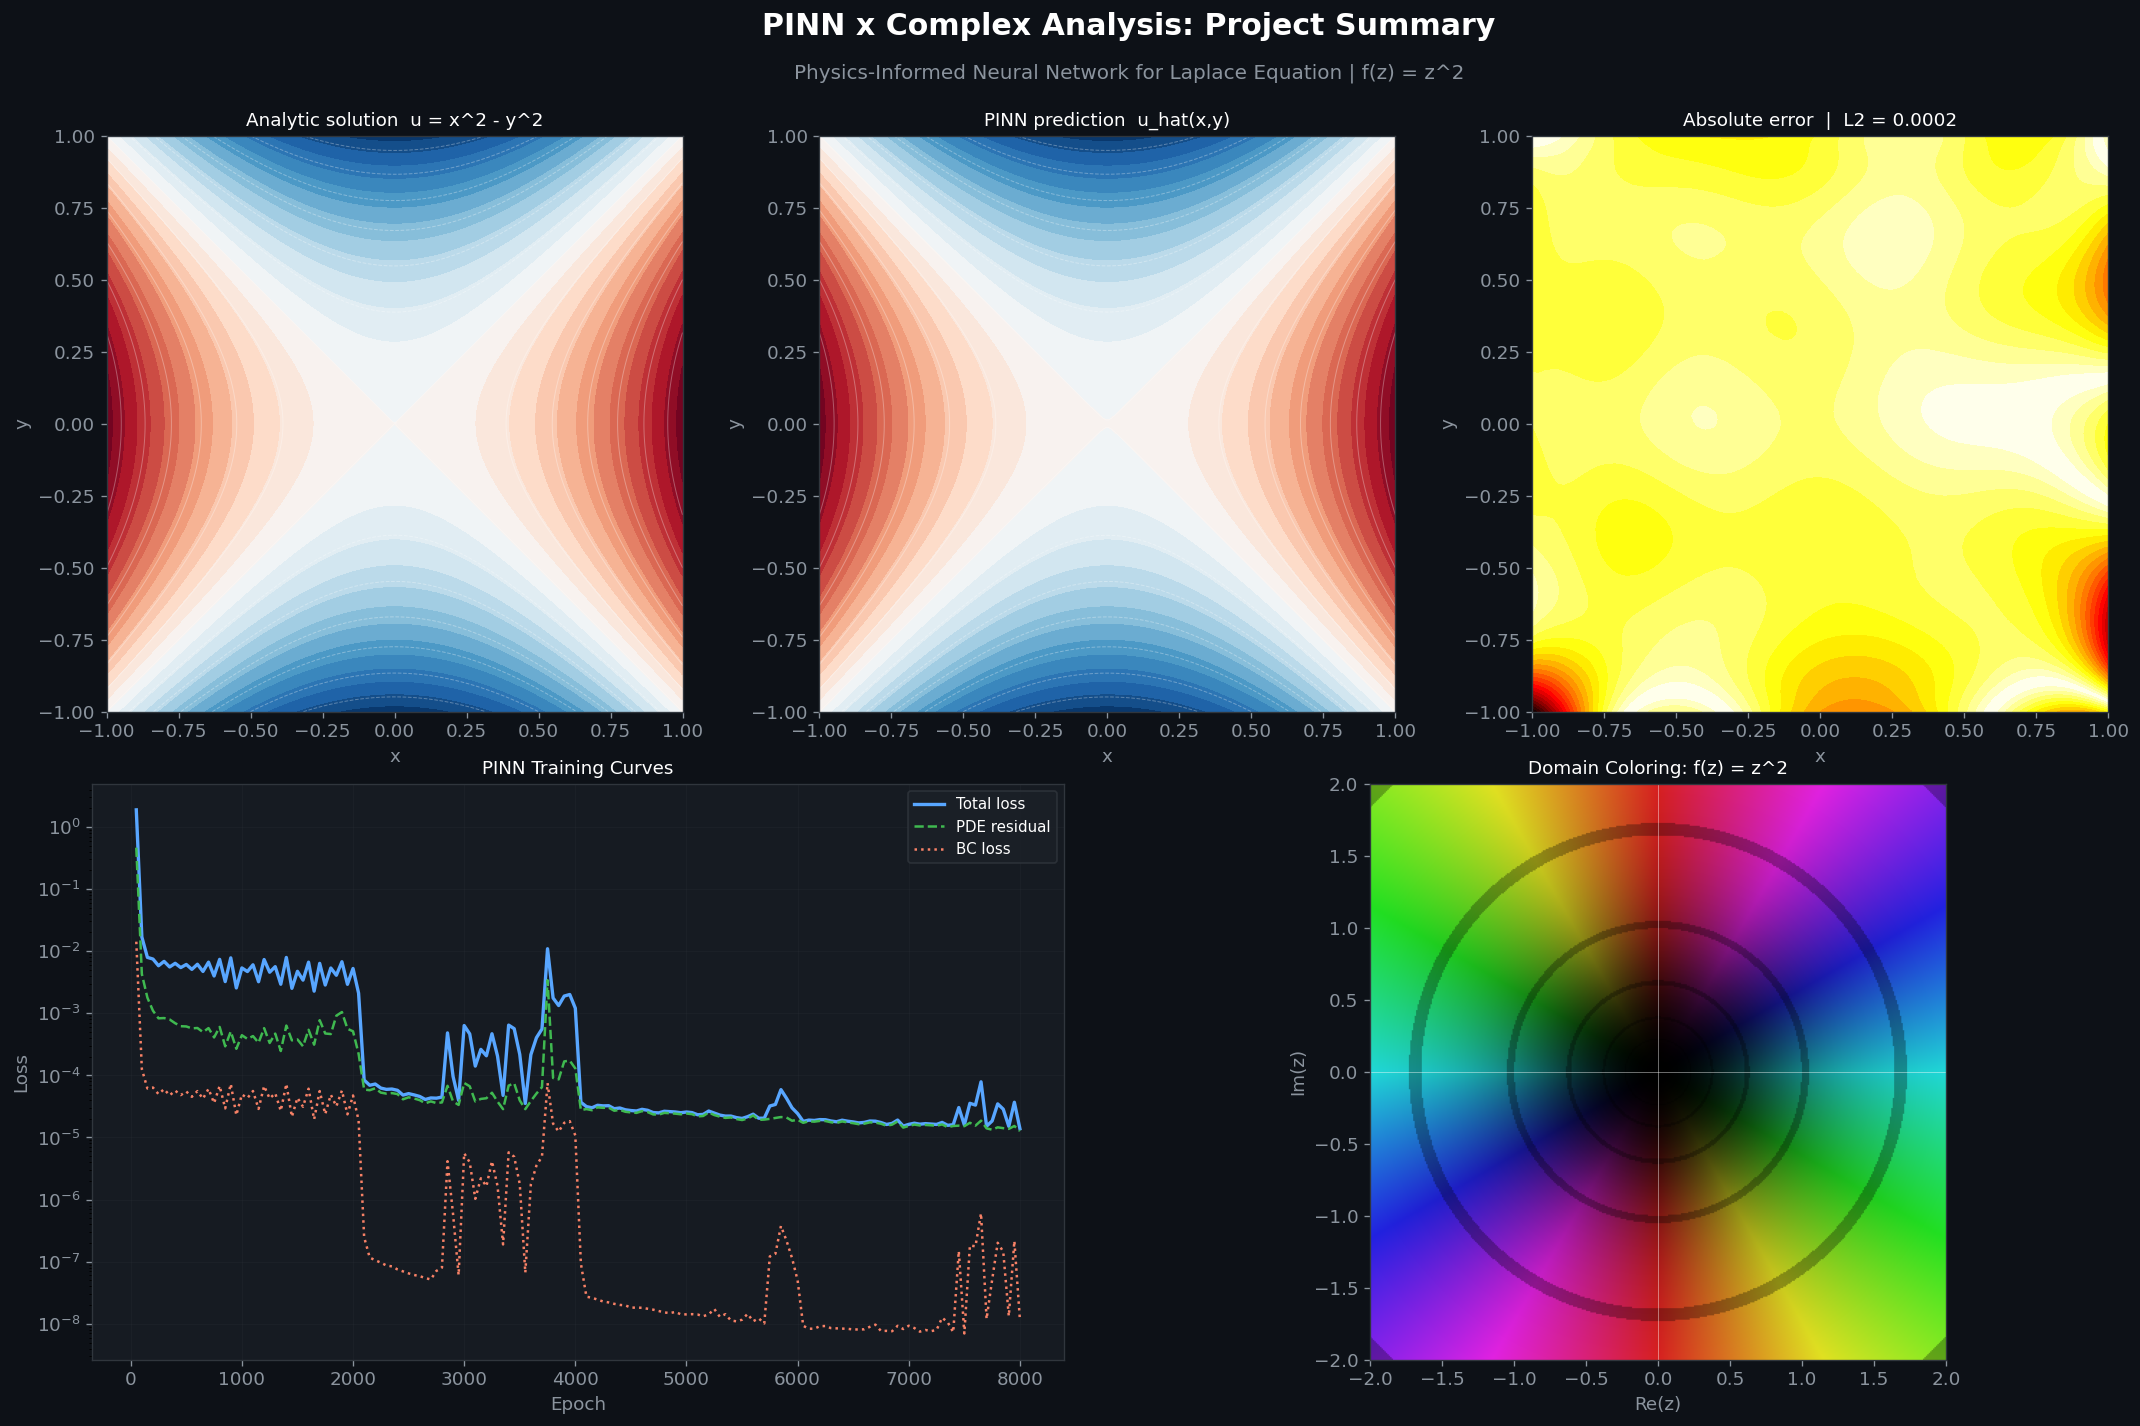


Project complete. Saved figures:
  final_summary.png  (755 KB)
  section2_analytic_solution.png  (543 KB)
  section3_training_curves.png  (198 KB)
  section3_training_points.png  (129 KB)
  section4_cross_section.png  (69 KB)
  section4_error_analysis.png  (305 KB)
  section5_harmonic_conjugate.png  (253 KB)
  section6_domain_coloring.png  (961 KB)
  section7_fluid_flow.png  (876 KB)

Final L2 error          : 0.000215
Total trainable params  : 12,737
The network learned the PDE solution from boundary data alone — no interior labels.


In [24]:
# ============================================================
# Final Summary: Combined Result Figure
# ============================================================

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#0d1117')

fig.text(0.5, 0.97, 'PINN x Complex Analysis: Project Summary',
         ha='center', fontsize=18, fontweight='bold', color='white')
fig.text(0.5, 0.94, 'Physics-Informed Neural Network for Laplace Equation | f(z) = z^2',
         ha='center', fontsize=12, color='#8b949e')

# Five sub-axes
ax1 = fig.add_axes([0.02, 0.50, 0.28, 0.40])   # analytic solution
ax2 = fig.add_axes([0.35, 0.50, 0.28, 0.40])   # PINN prediction
ax3 = fig.add_axes([0.68, 0.50, 0.28, 0.40])   # error map
ax4 = fig.add_axes([0.02, 0.05, 0.45, 0.40])   # loss curves
ax5 = fig.add_axes([0.52, 0.05, 0.45, 0.40])   # domain coloring

for ax in [ax1, ax2, ax3, ax4, ax5]:
    ax.set_facecolor('#161b22')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')
    ax.tick_params(colors='#8b949e')
    ax.xaxis.label.set_color('#8b949e')
    ax.yaxis.label.set_color('#8b949e')
    ax.title.set_color('white')

# ax1: analytic solution
ax1.contourf(X_eval, Y_eval, u_exact, levels=25, cmap='RdBu_r')
ax1.contour(X_eval, Y_eval, u_exact, levels=15, colors='white', alpha=0.3, linewidths=0.6)
ax1.set_title('Analytic solution  u = x^2 - y^2', fontsize=11)
ax1.set_xlabel('x'); ax1.set_ylabel('y')
ax1.set_aspect('equal')

# ax2: PINN prediction
ax2.contourf(X_eval, Y_eval, u_pred, levels=25, cmap='RdBu_r')
ax2.contour(X_eval, Y_eval, u_pred, levels=15, colors='white', alpha=0.3, linewidths=0.6)
ax2.set_title('PINN prediction  u_hat(x,y)', fontsize=11)
ax2.set_xlabel('x'); ax2.set_ylabel('y')
ax2.set_aspect('equal')

# ax3: error heatmap
ax3.contourf(X_eval, Y_eval, error, levels=25, cmap='hot_r')
ax3.set_title(f'Absolute error  |  L2 = {l2_error:.4f}', fontsize=11)
ax3.set_xlabel('x'); ax3.set_ylabel('y')
ax3.set_aspect('equal')

# ax4: training curves
ax4.semilogy(history['epoch'], history['total'], color='#58a6ff', linewidth=2,   label='Total loss')
ax4.semilogy(history['epoch'], history['pde'],   color='#3fb950', linewidth=1.5,
             linestyle='--', label='PDE residual')
ax4.semilogy(history['epoch'], [v / LAMBDA_BC for v in history['bc']],
             color='#f78166', linewidth=1.5, linestyle=':', label='BC loss')
ax4.set_xlabel('Epoch'); ax4.set_ylabel('Loss')
ax4.set_title('PINN Training Curves', fontsize=11)
ax4.legend(fontsize=9, facecolor='#1c2128', edgecolor='#30363d', labelcolor='white')
ax4.grid(True, alpha=0.2, color='#30363d')

# ax5: domain coloring
RGB_summary, xs, ys = domain_coloring(lambda z: z**2, N=400)
ax5.imshow(RGB_summary, extent=[-2, 2, -2, 2], origin='lower', aspect='equal')
ax5.axhline(y=0, color='white', linewidth=0.5, alpha=0.5)
ax5.axvline(x=0, color='white', linewidth=0.5, alpha=0.5)
ax5.set_title('Domain Coloring: f(z) = z^2', fontsize=11)
ax5.set_xlabel('Re(z)'); ax5.set_ylabel('Im(z)')

plt.savefig('final_summary.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print('\n' + '=' * 60)
print('Project complete. Saved figures:')
import os
saved_files = sorted(f for f in os.listdir('.') if f.endswith('.png'))
for f in saved_files:
    size = os.path.getsize(f) / 1024
    print(f'  {f}  ({size:.0f} KB)')
print('=' * 60)
print(f'\nFinal L2 error          : {l2_error:.6f}')
print(f'Total trainable params  : {total_params:,}')
print('The network learned the PDE solution from boundary data alone — no interior labels.')

---

## 學習連結：複變分析 ↔ PINN

| 複變分析概念 | 在本 Project 的體現 |
|------------|------------------|
| **Ch.2 Cauchy-Riemann 方程** | PINN 的 $u_x = v_y$ 條件驗證（Section 5） |
| **Ch.2 複微分** | `torch.autograd` = 解析函數微分的計算化身 |
| **Ch.4 解析函數** | $f(z) = z^2$ 的 harmonic function 性質 |
| **Ch.5 複線積分** | 從 $u_x$ 積分求 harmonic conjugate $v$（Section 5） |
| **保角映射（conformal map）** | Domain Coloring 展示角度保持（Section 6） |

---

## 延伸方向

1. **更複雜的邊界條件**：試試 $u|_{\partial D}$ 不是解析函數實部的情況
2. **Poisson 方程**：把 $\nabla^2 u = 0$ 改成 $\nabla^2 u = f$，對應有源場
3. **3D PINN**：把 $(x,y)$ 輸入擴展到 $(x,y,z)$，求三維 Laplace 方程
4. **Fourier 特徵嵌入**：改善 PINN 對高頻函數的逼近能力
5. **Ch.10-12 Residue Theorem**：用複變留數定理驗證某些定積分的數值結果

---
*Notebook 根據 Teh, Jyh-Haur《Lecture notes on complex analysis》（NTHU, 2026）延伸設計*

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


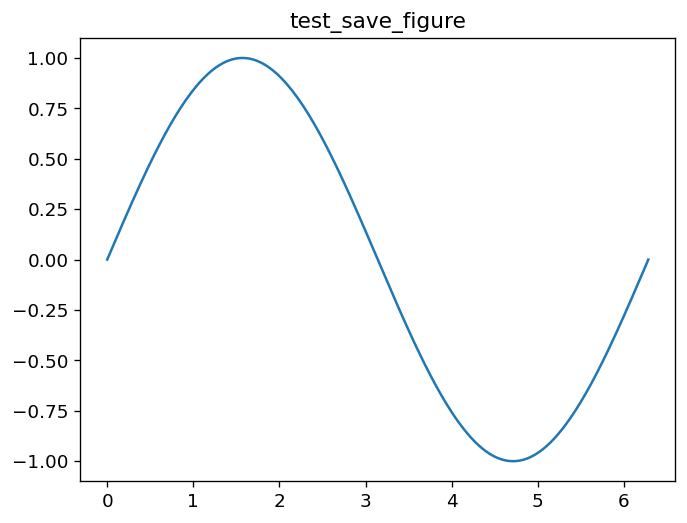

圖片已存到： /content/drive/MyDrive/PINN_Laplace_ComplexAnalysis/test_figure.png
目前資料夾內容：
['test_figure.png']


In [26]:
from google.colab import drive
drive.mount('/content/drive')

import os
import matplotlib.pyplot as plt
import numpy as np

SAVE_DIR = "/content/drive/MyDrive/PINN_Laplace_ComplexAnalysis"
os.makedirs(SAVE_DIR, exist_ok=True)

# 測試畫一張圖
x = np.linspace(0, 2*np.pi, 200)
y = np.sin(x)

plt.figure()
plt.plot(x, y)
plt.title("test_save_figure")

save_path = os.path.join(SAVE_DIR, "test_figure.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("圖片已存到：", save_path)
print("目前資料夾內容：")
print(os.listdir(SAVE_DIR))